1. SHAP Dependence Plot: How does Employment Rate interact with Age?


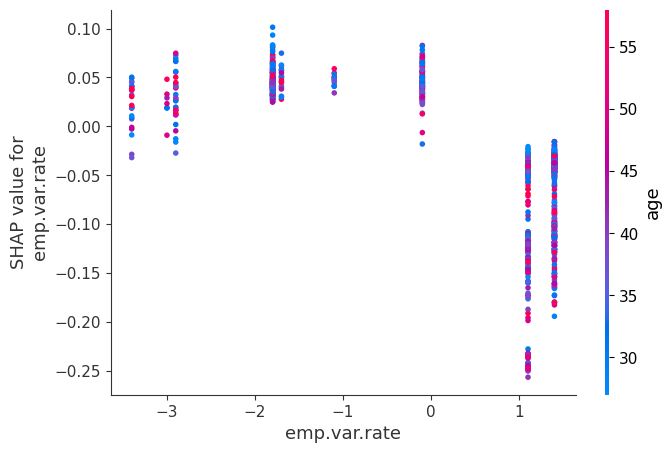


2. SHAP Waterfall Plot: Explaining a SINGLE Customer's Prediction
Customer Profile:
age                       30
campaign                   2
pdays                    999
emp.var.rate             1.1
cons.price.idx        93.994
euribor3m              4.857
nr.employed           5191.0
job_blue-collar         True
education_basic.9y      True
housing_yes             True
Name: 6810, dtype: object



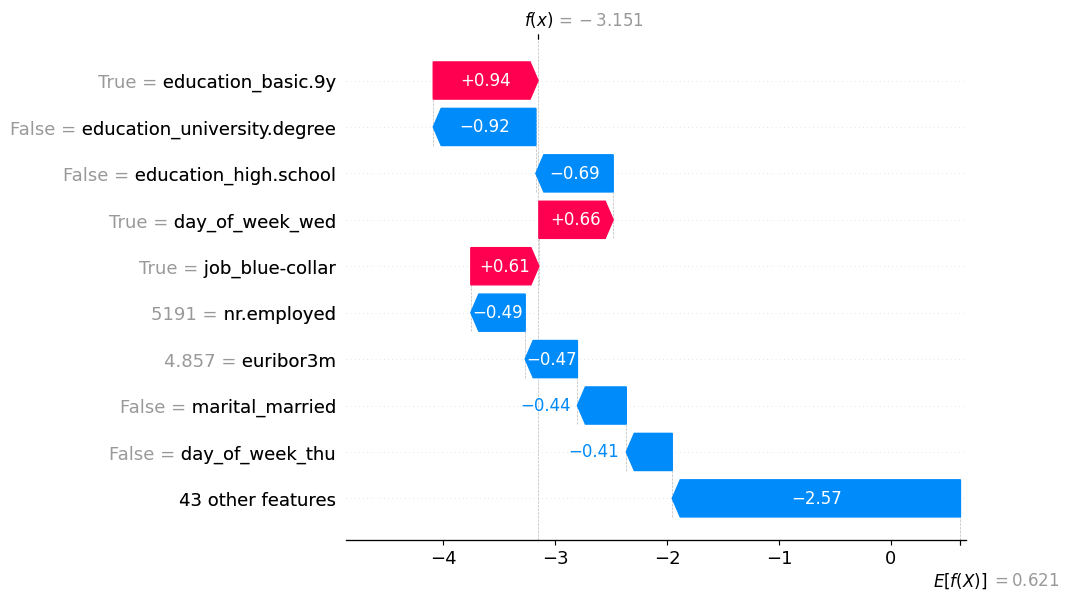

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Initialize JS for SHAP
shap.initjs()

# 1. Quick Prep & Train Winning Model (LightGBM)
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')
if 'duration' in df.columns: df = df.drop(columns=['duration'])
df['y'] = df['y'].map({'no': 0, 'yes': 1})

X = pd.get_dummies(df.drop(columns=['y']), drop_first=True)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

best_model = LGBMClassifier(random_state=42, verbose=-1)
best_model.fit(X_train_res, y_train_res)

# 2. Set up SHAP Explainer
explainer = shap.TreeExplainer(best_model)
# Sample to keep computation fast
X_test_sample = X_test.sample(n=1000, random_state=42)
shap_values = explainer(X_test_sample)

print("="*60)
print("1. SHAP Dependence Plot: How does Employment Rate interact with Age?")
print("="*60)

# FIX: Removed the [1] from explainer.shap_values
shap.dependence_plot("emp.var.rate", explainer.shap_values(X_test_sample), X_test_sample, interaction_index="age")
plt.show()

print("\n" + "="*60)
print("2. SHAP Waterfall Plot: Explaining a SINGLE Customer's Prediction")
print("="*60)

# Find a customer the model predicted strongly as "Yes" (Class 1)
customer_index = 5 
customer_data = X_test_sample.iloc[customer_index]

print(f"Customer Profile:\n{customer_data[customer_data > 0].head(10)}\n")

# Generate waterfall plot for this specific customer
shap.plots.waterfall(shap_values[customer_index])